# PCA Analysis in Python Explained (Scikit - Learn)

https://www.youtube.com/watch?v=6uwa9EkUqpg

In [1]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_csv('2022mlbteams.csv')
df

,Tm,#Bat,BatAge,R/G,G,PA,AB,R,H,2B,...,OPS,OPS+,TB,GDP,HBP,SH,SF,IBB,LOB,Playoffs
0,Arizona Diamondbacks,57,26.5,4.33,162,6027,5351,702,1232,262,...,0.689,95,2061,97,60,31,50,14,1039,0
1,Atlanta Braves,53,27.5,4.87,162,6082,5509,789,1394,298,...,0.761,109,2443,103,66,1,36,13,1030,1
2,Baltimore Orioles,58,27.0,4.16,162,6049,5429,674,1281,275,...,0.695,99,2119,95,83,12,43,10,1095,0
3,Boston Red Sox,54,28.8,4.54,162,6144,5539,735,1427,352,...,0.731,102,2268,131,63,12,50,23,1133,0
4,Chicago Cubs,64,27.9,4.06,162,6072,5425,657,1293,265,...,0.698,94,2097,130,84,19,36,16,1100,0
5,Chicago White Sox,44,29.3,4.23,162,6123,5611,686,1435,272,...,0.698,97,2172,127,73,16,35,9,1117,0
6,Cincinnati Reds,66,29.4,4.00,162,5978,5380,648,1264,235,...,0.676,85,2003,127,92,12,33,6,1020,0
7,Cleveland Guardians,50,25.9,4.31,162,6163,5558,698,1410,273,...,0.699,102,2126,119,81,22,52,36,1156,1
8,Colorado Rockies,43,29.1,4.31,162,6105,5540,698,1408,280,...,0.713,91,2203,139,61,10,40,10,1113,0
9,Detroit Tigers,53,27.9,3.44,162,5870,5378,557,1240,235,...,0.632,82,1859,108,58,10,44,8,1015,0


In [10]:
df.drop('Tm', axis=1, inplace=True)
df

,#Bat,BatAge,R/G,G,PA,AB,R,H,2B,3B,...,OPS,OPS+,TB,GDP,HBP,SH,SF,IBB,LOB,Playoffs
0,57,26.5,4.33,162,6027,5351,702,1232,262,24,...,0.689,95,2061,97,60,31,50,14,1039,0
1,53,27.5,4.87,162,6082,5509,789,1394,298,11,...,0.761,109,2443,103,66,1,36,13,1030,1
2,58,27.0,4.16,162,6049,5429,674,1281,275,25,...,0.695,99,2119,95,83,12,43,10,1095,0
3,54,28.8,4.54,162,6144,5539,735,1427,352,12,...,0.731,102,2268,131,63,12,50,23,1133,0
4,64,27.9,4.06,162,6072,5425,657,1293,265,31,...,0.698,94,2097,130,84,19,36,16,1100,0
5,44,29.3,4.23,162,6123,5611,686,1435,272,9,...,0.698,97,2172,127,73,16,35,9,1117,0
6,66,29.4,4.00,162,5978,5380,648,1264,235,18,...,0.676,85,2003,127,92,12,33,6,1020,0
7,50,25.9,4.31,162,6163,5558,698,1410,273,31,...,0.699,102,2126,119,81,22,52,36,1156,1
8,43,29.1,4.31,162,6105,5540,698,1408,280,34,...,0.713,91,2203,139,61,10,40,10,1113,0
9,53,27.9,3.44,162,5870,5378,557,1240,235,27,...,0.632,82,1859,108,58,10,44,8,1015,0


In [15]:
X = df.iloc[:, 0:28]
y = df.iloc[:, 28]

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.preprocessing import StandardScaler
scaleStandard = StandardScaler()
X_train = scaleStandard.fit_transform(X_train)

In [24]:
df.columns

Index(['#Bat', 'BatAge', 'R/G', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR',
       'RBI', 'SB', 'CS', 'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'OPS+', 'TB',
       'GDP', 'HBP', 'SH', 'SF', 'IBB', 'LOB', 'Playoffs'],
      dtype='object')

In [25]:
X_train = pd.DataFrame(X_train, columns=['#Bat', 'BatAge', 'R/G', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR',
       'RBI', 'SB', 'CS', 'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'OPS+', 'TB',
       'GDP', 'HBP', 'SH', 'SF', 'IBB', 'LOB'])
X_train.head(10)

,#Bat,BatAge,R/G,G,PA,AB,R,H,2B,3B,...,SLG,OPS,OPS+,TB,GDP,HBP,SH,SF,IBB,LOB
0,-0.879525,-0.853104,1.111446,0.0,0.972487,1.428581,1.119975,1.735023,1.216811,-1.087008,...,1.394239,1.455725,1.762953,1.515946,1.477575,-0.910119,-0.698464,-0.999056,-0.331813,0.486216
1,1.431636,1.590355,0.299019,0.0,0.529260,-0.778610,0.299124,-0.791286,-0.435616,-0.345164,...,-0.214121,-0.056122,-0.008684,-0.350811,-0.247594,2.221473,-0.960387,1.607177,-0.211154,0.567111
2,1.431636,-0.179047,-0.987325,0.0,-0.984198,-0.358838,-0.994760,-0.741507,-1.579603,1.262166,...,-0.214121,-0.550908,-0.738182,-0.255568,-1.142125,-0.988408,1.527889,-2.041550,1.478078,-0.747441
3,0.044939,-1.358648,0.095912,0.0,-0.443678,-1.333794,0.104345,-1.152188,-0.213174,0.396681,...,-0.410263,-0.495932,-0.529754,-0.604791,-1.014335,-0.518670,2.313661,1.216242,-0.211154,-0.969903
4,1.123481,-0.179047,-0.513409,0.0,0.042791,-0.331756,-0.521727,-0.393051,-0.117841,1.262166,...,-0.331806,-0.248538,-0.633968,-0.376209,1.094204,1.360285,0.742118,-0.608121,0.030165,0.263753
5,0.661249,-1.021619,0.028209,0.0,0.486018,0.358838,0.020869,0.390976,0.009268,-0.345164,...,0.217390,0.301224,0.512385,0.246044,1.285889,-0.362090,-0.436540,0.694996,-0.573132,0.789574
6,-1.958067,1.000554,-0.129763,0.0,0.594123,2.186880,-0.118258,1.374121,0.104601,-1.457930,...,-0.331806,-0.248538,-0.321326,0.100005,0.902519,0.499097,0.349232,-0.738433,-0.814451,0.607559
7,-0.879525,1.253326,2.126981,0.0,1.934614,1.035890,2.121691,1.162558,1.788805,1.262166,...,1.825751,1.868047,1.554525,1.808024,-1.781077,-0.831829,-1.353273,1.607177,0.754121,1.456962
8,-0.263216,-0.853104,-0.761651,0.0,-0.627455,-0.169263,-0.758244,0.030075,-0.689835,2.127651,...,-0.606404,-0.578396,-0.738182,-0.585743,-0.758755,-1.458147,0.873079,0.434372,-1.055770,0.081738
9,-0.263216,0.073725,0.141046,0.0,1.156264,0.250509,0.146084,-0.094374,0.199933,-0.345164,...,-0.527948,-0.193562,0.199743,-0.439704,-1.142125,-0.127221,0.480194,0.694996,0.995440,1.760320


In [27]:
X_train.describe().round(3)

,#Bat,BatAge,R/G,G,PA,AB,R,H,2B,3B,...,SLG,OPS,OPS+,TB,GDP,HBP,SH,SF,IBB,LOB
count,24.000,24.000,24.000,24.0,24.000,24.000,24.000,24.000,24.000,24.000,...,24.000,24.000,24.000,24.000,24.000,24.000,24.000,24.000,24.000,24.000
mean,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,-0.000,0.000,...,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000
std,1.022,1.022,1.022,0.0,1.022,1.022,1.022,1.022,1.022,1.022,...,1.022,1.022,1.022,1.022,1.022,1.022,1.022,1.022,1.022,1.022
min,-1.958,-1.864,-1.755,0.0,-2.217,-1.835,-1.760,-2.210,-1.580,-1.582,...,-1.940,-2.228,-1.676,-2.027,-1.781,-1.458,-1.615,-2.042,-1.176,-2.386
25%,-0.648,-0.874,-0.677,0.0,-0.676,-0.596,-0.675,-0.745,-0.634,-0.778,...,-0.636,-0.558,-0.660,-0.621,-1.030,-0.773,-0.862,-0.804,-0.603,-0.773
50%,-0.186,0.032,0.039,0.0,0.070,-0.244,0.035,-0.032,-0.054,-0.222,...,-0.273,-0.235,-0.061,-0.246,0.072,-0.323,-0.175,0.109,-0.271,0.142
75%,0.777,0.748,0.626,0.0,0.859,0.674,0.626,0.845,0.534,1.015,...,0.982,0.906,0.851,0.894,0.903,0.636,0.775,0.695,0.392,0.653
max,1.740,1.759,2.127,0.0,1.935,2.187,2.122,1.735,2.647,2.128,...,1.865,1.868,1.763,1.821,1.797,2.221,2.314,1.607,2.443,1.760


In [ ]:
from sklearn.decomposition import PCA

In [32]:
pca1 = PCA()
X_pca1 = pca1.fit_transform(X_train)
pca1.explained_variance_ratio_

array([4.88465802e-01, 1.14888391e-01, 8.82560885e-02, 7.51803674e-02,
       4.57228211e-02, 4.26488883e-02, 3.61749758e-02, 2.84702775e-02,
       2.17481140e-02, 1.85975758e-02, 1.35834252e-02, 9.90120902e-03,
       6.10128452e-03, 4.69041209e-03, 3.22128236e-03, 1.45075383e-03,
       7.16651409e-04, 8.22546015e-05, 6.93012135e-05, 2.01615286e-05,
       7.57604380e-06, 1.78174004e-06, 6.05157417e-07, 4.70993351e-34])

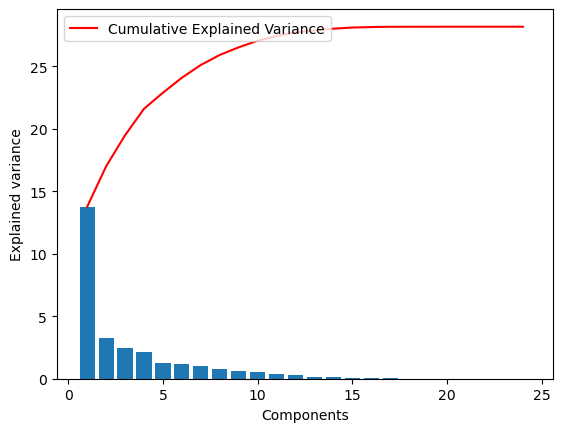

In [33]:
# Prasad Ostwal Github
import matplotlib.pyplot as plt
plt.bar(range(1,len(pca1.explained_variance_ )+1),pca1.explained_variance_ )
plt.ylabel('Explained variance')
plt.xlabel('Components')
plt.plot(range(1,len(pca1.explained_variance_ )+1),
         np.cumsum(pca1.explained_variance_),
         c='red',
         label="Cumulative Explained Variance")
plt.legend(loc='upper left')

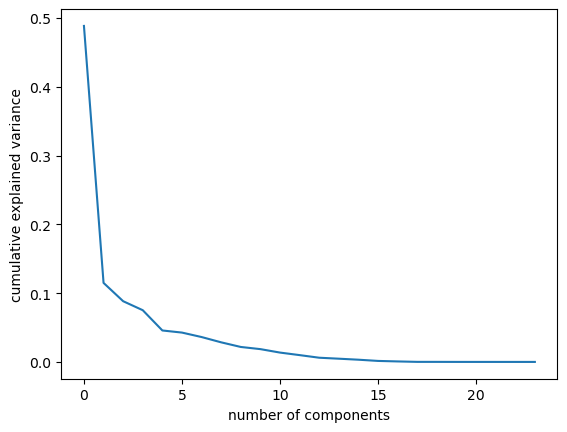

In [34]:
plt.plot(pca1.explained_variance_ratio_)
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

In [37]:
pca2 = PCA(0.95)
X_pca2 = pca2.fit_transform(X_train)
print(X_pca2.shape)
pca2.explained_variance_ratio_

(24, 10)


array([0.4884658 , 0.11488839, 0.08825609, 0.07518037, 0.04572282,
       0.04264889, 0.03617498, 0.02847028, 0.02174811, 0.01859758])

In [39]:
pca2c = PCA(n_components=2)
X_pca2c = pca2c.fit_transform(X_train)

C:\Users\jc\AppData\Local\Temp\ipykernel_31292\198320428.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('coolwarm')


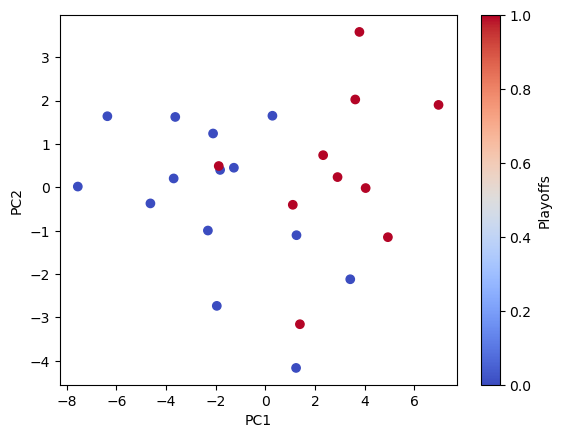

In [40]:
colormap = plt.cm.get_cmap('coolwarm')

plt.figure()
scatter = plt.scatter(X_pca2c[:, 0], X_pca2c[:, 1], c=y_train, cmap=colormap)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Playoffs')
plt.show()

In [42]:
pca3c = PCA(n_components=3)
X_pca3c = pca3c.fit_transform(X_train)
pca3c.explained_variance_ratio_

array([0.4884658 , 0.11488839, 0.08825609])

C:\Users\jc\AppData\Local\Temp\ipykernel_31292\3289885450.py:16: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label='Playoffs')


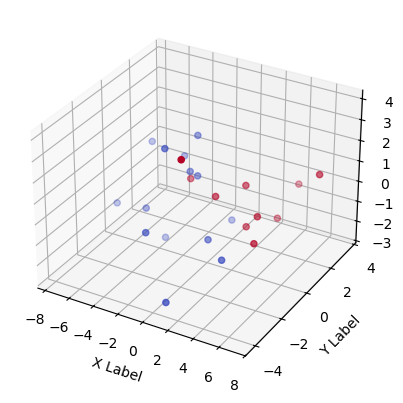

In [43]:
from mpl_toolkits.mplot3d import Axes3D  # Import the 3D plotting toolkit

# Create a figure and a 3D axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
ax.scatter(X_pca3c[:,0], X_pca3c[:,1], X_pca3c[:,2], c=y_train, cmap=colormap)

# Set labels for the axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# Show the plot
plt.colorbar(scatter, label='Playoffs')
plt.show()